# Train a synthetic graph model

**Purpose:** Train a synthetic graph model.

**Before you start:** NSPPK; generated data. Use the Python environment prepared by [setup](../setup.ipynb).

**Results:** Saved model, dataset configuration, and sample plots.

Run the cells in order, reviewing the configuration before starting the main work. Data stays under `notebooks/datasets`; models and outputs use the project’s artifact folders.


Load the notebook tools and locate the data and output folders.


In [1]:
print('Load the notebook tools and locate the data and output folders.')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import random
import warnings
import numpy as np

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.demo.artificial import generate_artificial_dataset


Load the notebook tools and locate the data and output folders.
PyTorch version: 2.13.0
CUDA available: False


Choose the dataset size, training settings, and output name.


In [2]:
print('Choose the dataset size, training settings, and output name.')
RANDOM_SEED = 42
DATASET_SIZE =4500
N_ITERATIONS = 1
CYCLE_LENGTH = [3,8]
NUM_CYCLES = 1
PATH_LENGTH = 2
NUM_RAYS = 3
RAY_LENGTH = 1
NODE_ALPHABET_SIZE = 3
EDGE_ALPHABET_SIZE = 1
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True

FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10
EMBEDDING_DIM = 128
CYCLE_COUNT_TOKEN = '' if NUM_CYCLES == 1 else f'-nc{NUM_CYCLES}'
ITERATION_COUNT_TOKEN = '' if N_ITERATIONS == 1 else f'-ni{N_ITERATIONS}'
CYCLE_LENGTH_TOKEN = '-'.join(str(value) for value in CYCLE_LENGTH) if isinstance(CYCLE_LENGTH, (list, tuple)) else str(CYCLE_LENGTH)
MODEL_NAME = (
    f'artificial-cycle-path-star-n{DATASET_SIZE}'
    f'-c{CYCLE_LENGTH_TOKEN}{CYCLE_COUNT_TOKEN}{ITERATION_COUNT_TOKEN}-p{PATH_LENGTH}-r{NUM_RAYS}x{RAY_LENGTH}'
    f'-d{EMBEDDING_DIM}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)




Choose the dataset size, training settings, and output name.


Generate the synthetic training graphs and save their configuration for reuse.


Generate the synthetic training graphs and save their configuration for reuse.
Saved artificial dataset config: artificial-cycle-path-star-n4500-c3-8-p2-r3x1-na3.yaml
Loaded 4500 artificial graphs into memory for non-streaming fit.
Node count min/median/max = 9/12/14
Edge count min/median/max = 9/12/14
Metadata: {'cycle_length': 8, 'num_cycles': 1, 'n_iterations': 1, 'path_length': 2, 'num_rays': 3, 'ray_length': 1, 'iteration_parameters': [{'cycle_length': 8, 'num_cycles': 1, 'path_length': 2, 'num_rays': 3, 'ray_length': 1}], 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0], 'path': [1], 'star': [2]}}


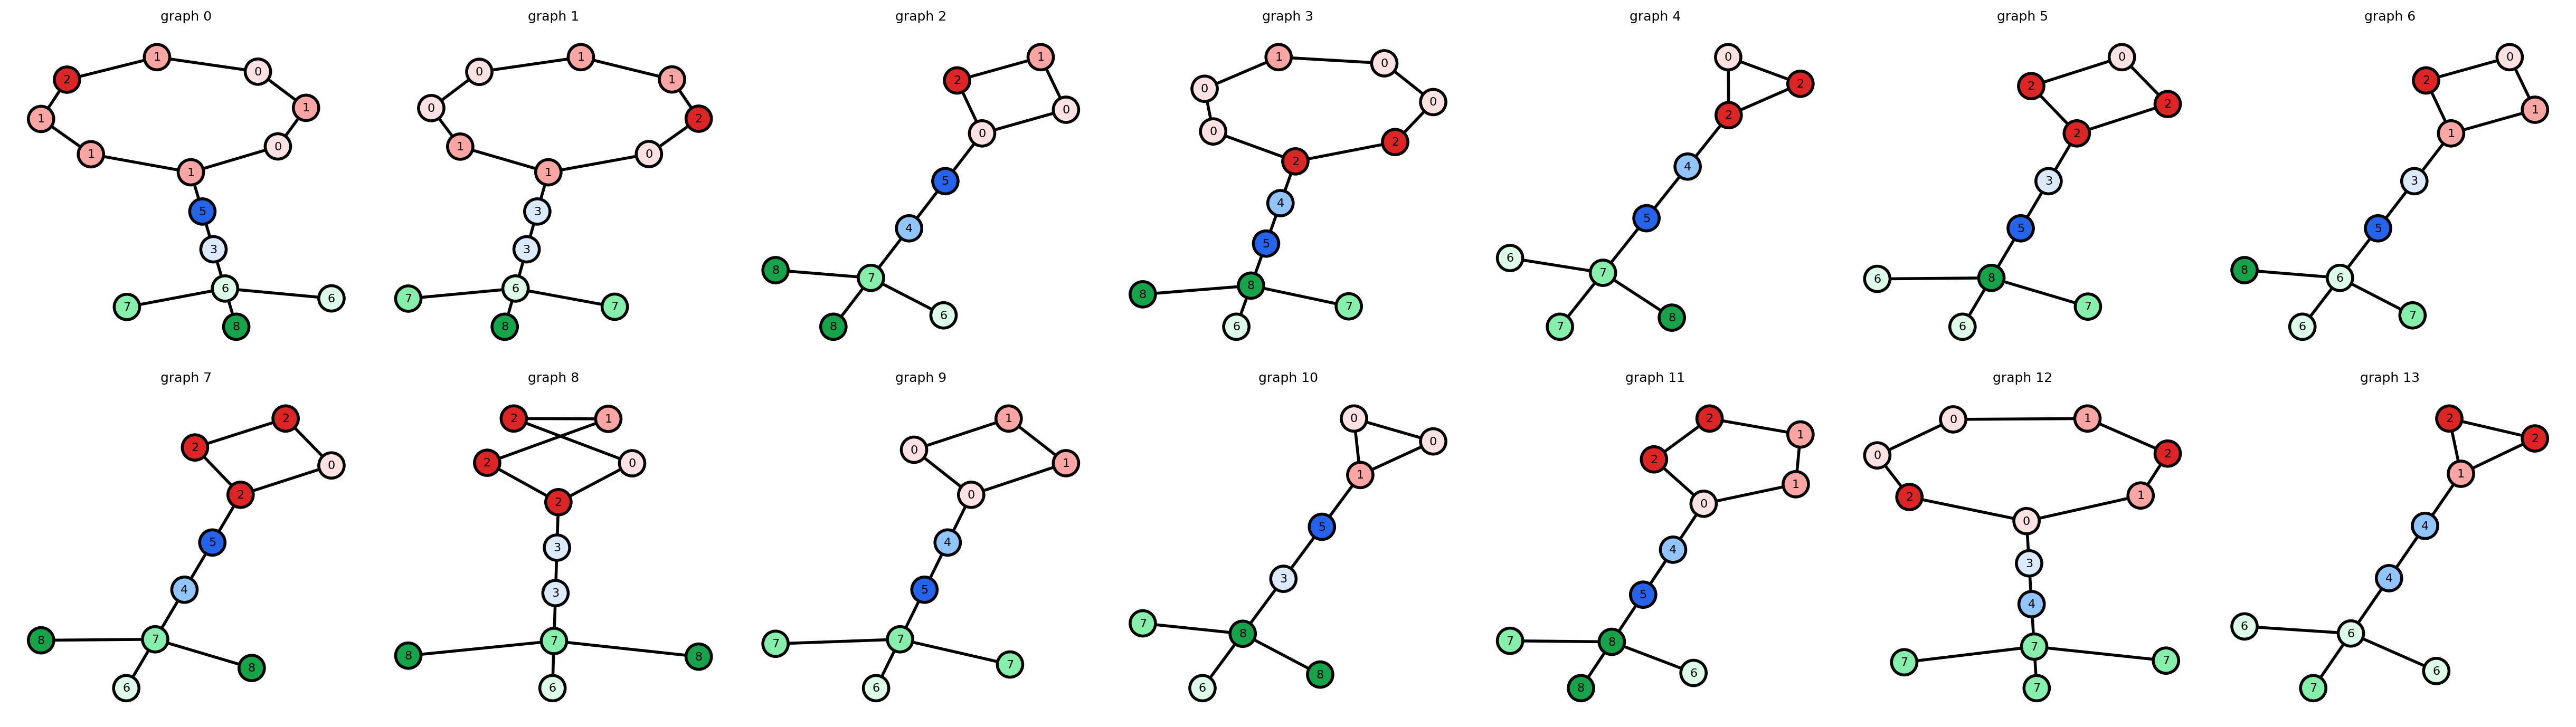

In [3]:
print('Generate the synthetic training graphs and save their configuration for reuse.')
graphs, plot_artificial_graphs = generate_artificial_dataset(
    num_graphs=DATASET_SIZE,
    n_iterations=N_ITERATIONS,
    cycle_length=CYCLE_LENGTH,
    num_cycles=NUM_CYCLES,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
    save_config_dir=REPO_ROOT / 'notebooks' / 'configs' / 'artificial_datasets',
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs into memory for non-streaming fit.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

num=7*2
_ = plot_artificial_graphs(
    graphs[:num],
    n_cols=7,
    titles=[f'graph {idx}' for idx in range(num)],
    size=3.5,
)



Build the generator and prepare the graph display used during training.


In [4]:
print('Build the generator and prepare the graph display used during training.')

# Recurrent energy setup. Set node_field_mode to "baseline" for the original model.
NODE_FIELD_CONFIG = {
    "node_field_mode": "recurrent_energy",
    "recurrent_hidden_dimension": None,  # None uses latent_embedding_dimension.
    "recurrent_training_steps": 8,
    "recurrent_detach_interval": 4,  # None keeps full backpropagation through memory.
    "recurrent_update_scale": 1.0,
    "recurrent_initial_state": "zeros",
    "recurrent_state_normalization": True,
    "recurrent_corruption_schedule": "annealed",  # Also "constant" or "none".
    "recurrent_sigma_min": 0.02,
    "recurrent_sigma_max": None,  # None uses node_field_sigma.
    "recurrent_supervise_all_steps": True,
    "recurrent_loss_discount": 1.0,
}

# Keep new model artifacts distinct from existing baseline checkpoints.
MODEL_NAME = (
    MODEL_NAME.removesuffix("-baseline").removesuffix("-recurrent_energy")
    + "-" + NODE_FIELD_CONFIG["node_field_mode"]
)

graph_generator = build_graph_generator(
    **NODE_FIELD_CONFIG,
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    locality_horizon=2,
    sparse_supervision_mask_ratio=0.5,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS
def render_artificial_graphs(decoded_graphs, **kwargs):
    graph_list = list(decoded_graphs)
    titles = kwargs.get('titles')
    plot_artificial_graphs(
        graph_list,
        n_cols=max(1, min(7, len(graph_list))),
        titles=titles,
    )


graph_generator.graph_decoder.diagnostic_graph_renderer = render_artificial_graphs

TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')

Build the generator and prepare the graph display used during training.
Configured graph generator model_name=artificial-cycle-path-star-n4500-c3-8-p2-r3x1-d128-b128-e350-recurrent-energy model_dir=/Users/f.costa/Code/NodeField/.artifacts/saved_generators
Training sample PDF: /Users/f.costa/Code/NodeField/.artifacts/samples/artificial-cycle-path-star-n4500-c3-8-p2-r3x1-d128-b128-e350-recurrent_energy/training_samples.pdf


Train the generator on the synthetic graphs. This may take some time.


Train the generator on the synthetic graphs. This may take some time.
________________________________________________________________________________
Training target: model 'artificial-cycle-path-star-n4500-c3-8-p2-r3x1-d128-b128-e350-recurrent-energy'. Saved model files will go to '/Users/f.costa/Code/NodeField/.artifacts/saved_generators'.
________________________________________________________________________________
Starting training on 4,500 synthetic graphs. Next, the generator will learn graph representations, prepare its training targets, and train the neural graph generator. This may take some time.
________________________________________________________________________________
Step 1 of 11 | Next: learn how to describe each complete graph with numeric features. Purpose: The generator will use this representation to understand each graph as a whole.
Step 1 of 11 | Done: Learned complete-graph features from 4,500 graphs. Time: 0m 0.0s.
_______________________________________

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 10/350 | ETA 1h 24m 28s:
  train total=   632.82 | node_field    626.13 [98.9%] |        deg   0.29711 [<0.1%] |      exist   0.27587 [<0.1%] | node_count   0.00521 [<0.1%]
  val   total=   625.21 | node_field    618.77 [99.0%] |        deg   0.25571 [<0.1%] |      exist   0.27476 [<0.1%] | node_count   0.00586 [<0.1%]
  train                 | node_label   0.46151 [<0.1%] | edge_label   0.09456 [<0.1%] |       edge   0.92673 [0.1%] | edge_count    4.2591 [0.7%] | deg_edge_consistency   0.00017 [<0.1%]
  val                   | node_label   0.38339 [<0.1%] | edge_label   0.07304 [<0.1%] |       edge   0.85786 [0.1%] | edge_count    4.2402 [0.7%] | deg_edge_consistency   0.00012 [<0.1%]
  train                 |        aux   0.37069 [<0.1%] | dominant=node_field [98.9%]
  val                   |        aux   0.34191 [<0.1%] | dominant=node_field [99.0%]
Epoch 20/350 | ETA 1h 21m 38s:
  train total=   601.52 | node_field    595.31 [99.0%] |        deg   0.30346 [<0.1%] |      exist

`Trainer.fit` stopped: `max_epochs=350` reached.


Restored best checkpoint: best_epoch=350, val_total=454.4192, raw_val_node_field=451.2197, stopped_epoch=351
  path=/Users/f.costa/Code/NodeField/.artifacts/checkpoints/node_field/ConditionalNodeFieldGenerator_5b410d603037485285dc61005a9c2c10/best-349-454.4192.ckpt


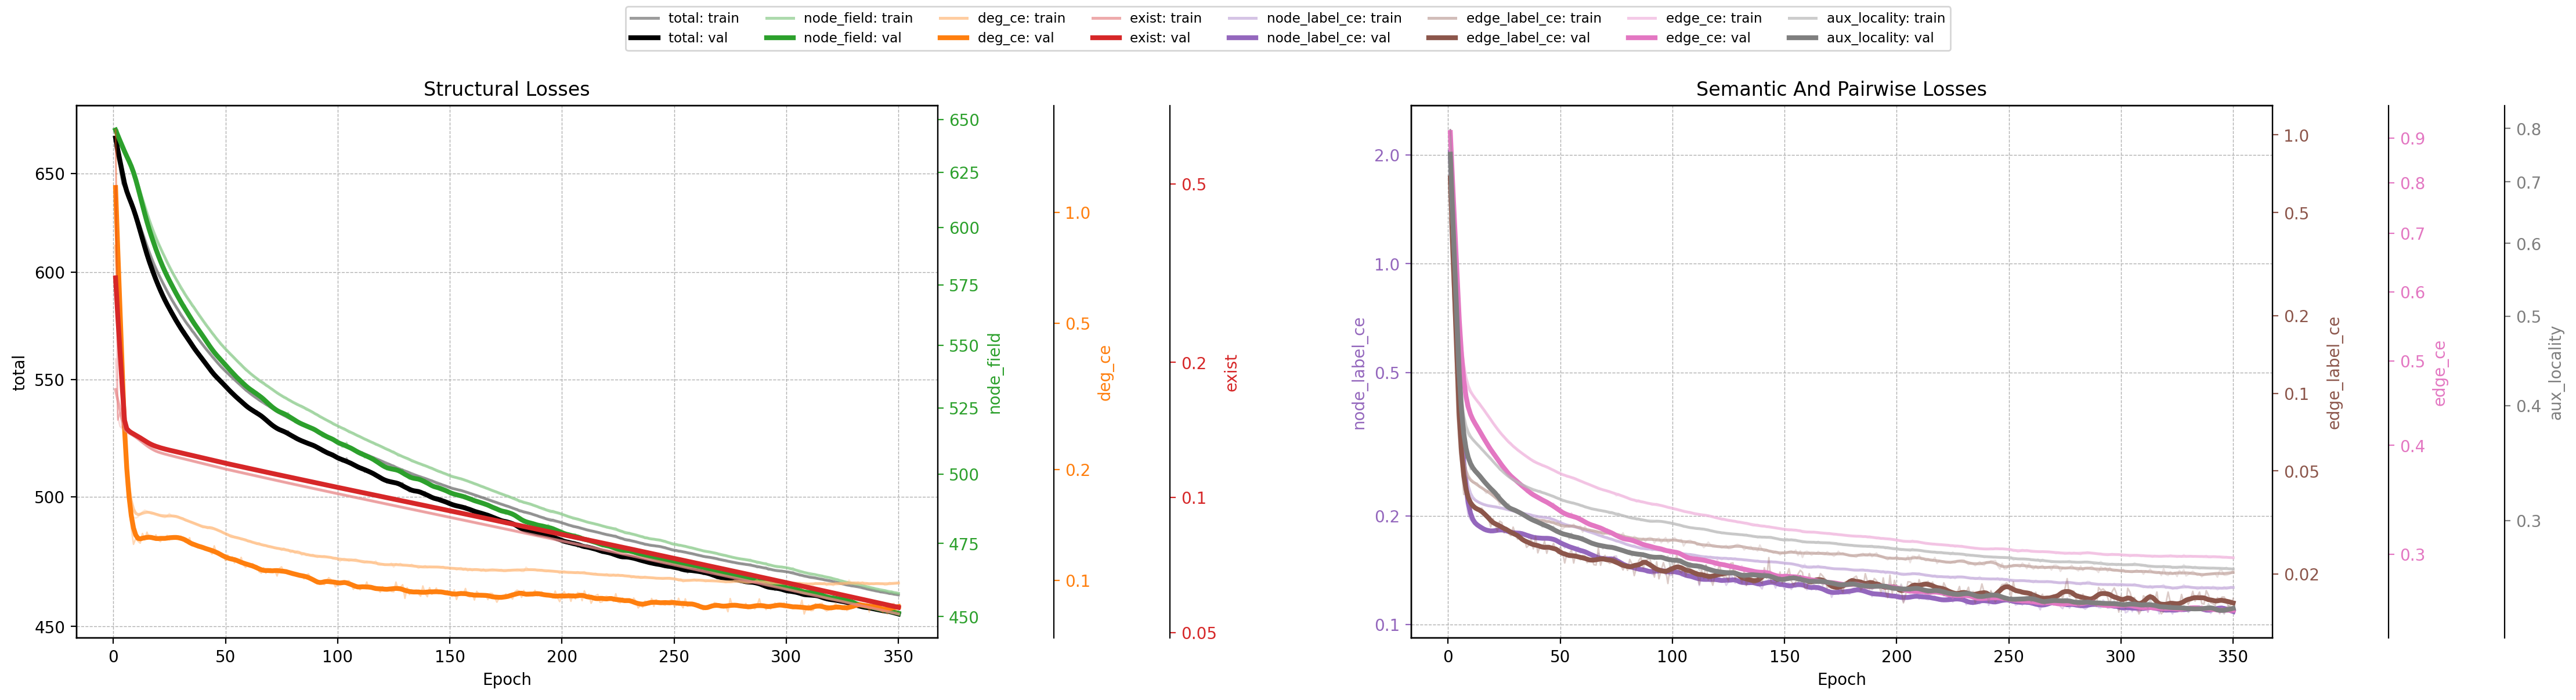

Done: the neural graph generator finished training. Time: 83m 37.2s.
________________________________________________________________________________
Training complete: The generator is ready to create graphs. Total time: 84m 0.4s.
training_graph_conditioning_ = 4500
is_fitted_ = True
CPU times: user 43min 45s, sys: 7min 58s, total: 51min 44s
Wall time: 1h 24min


In [5]:
%%time
print('Train the generator on the synthetic graphs. This may take some time.')
graph_generator.fit(
    graphs,
    sample_training_progress=False,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=30,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_fn=plot_artificial_graphs,
)
print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


Optionally reload a saved generator for later inspection.


In [6]:
print('Optionally reload a saved generator for later inspection.')
# Optional reload path for a previously saved artificial non-streaming model.
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)

list_saved_graph_generators(SAVED_GENERATOR_ROOT)
MODEL_FILENAME = f'{MODEL_NAME}.pkl'
graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


Optionally reload a saved generator for later inspection.


,name,modified,size_mb
0,artificial-cycle-path-star-n4500-c3-8-p2-r3x1-d128-b128-e350-recurrent-energy.pkl,2026-09-05 12:18,16.200000
1,artificial-cycle-path-star-n50000-c3-8-p2-r3x1-d128-b128-e350-recurrent-energy.pkl,2026-09-05 10:50,61.300000
2,artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-09-05 10:35,61.000000
3,artificial-partial-token-reconstruct-n900-remove50-d128-b128-e350.pkl,2026-07-23 15:50,12.300000
4,zinc-d80-n108642-size10-22.pkl,2026-07-17 01:13,226.300000
5,zinc-d80-n10000-size10-18.pkl,2026-07-16 16:23,32.100000
6,zinc-d80-n2250-size10-18.pkl,2026-07-16 15:39,16.900000
7,zinc-d80-n225-size10-18.pkl,2026-07-16 15:20,12.300000
8,artificial-cycle-path-star-n10000-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-07-16 15:12,21.300000
9,artificial-cycle-path-star-n1000-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-07-16 14:46,12.400000


Loaded graph generator: artificial-cycle-path-star-n4500-c3-8-p2-r3x1-d128-b128-e350-recurrent-energy.pkl
/Users/f.costa/Code/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n4500-c3-8-p2-r3x1-d128-b128-e350-recurrent-energy.pkl


Generate samples and display the results with feasibility filtering.


In [ ]:
print('Generate samples and display the results with feasibility filtering.')
N_SAMPLES = 8
FEASIBILITY_EFFORT = 2
FEASIBILITY_FILTER = 'none' # 'none', 'fallback', or 'strict'
filtered_samples = graph_generator.sample(
    n_samples=N_SAMPLES,
    feasibility_effort=FEASIBILITY_EFFORT,
    feasibility_filter=FEASIBILITY_FILTER,
)
_ = plot_artificial_graphs(
    filtered_samples,
    n_cols=N_SAMPLES,
    titles=[f'{idx}' for idx in range(len(filtered_samples))],
)

Generate samples and display the results with feasibility filtering.


Compare the graphs produced at each decoding stage.


Compare the graphs produced at each decoding stage.


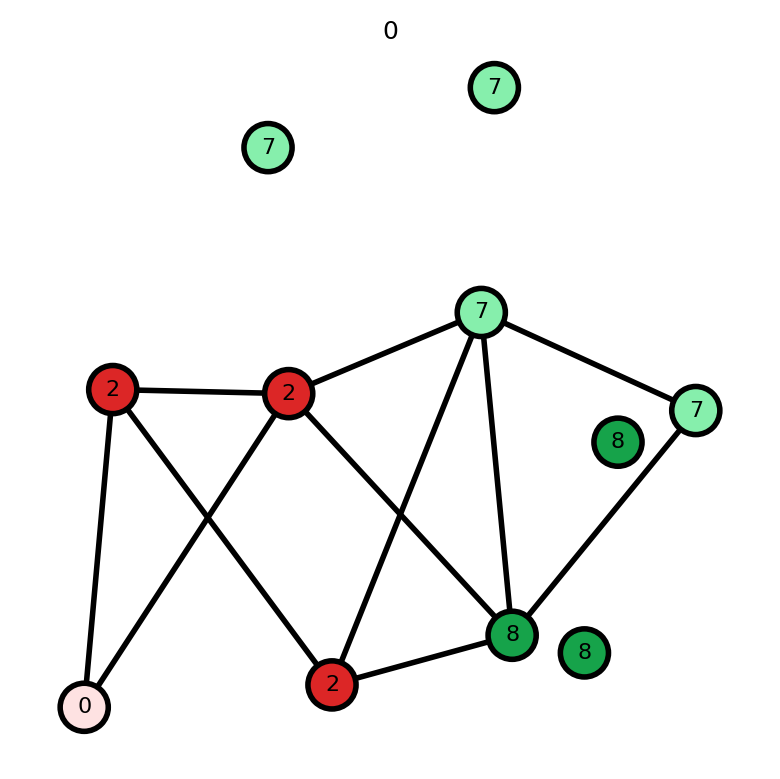

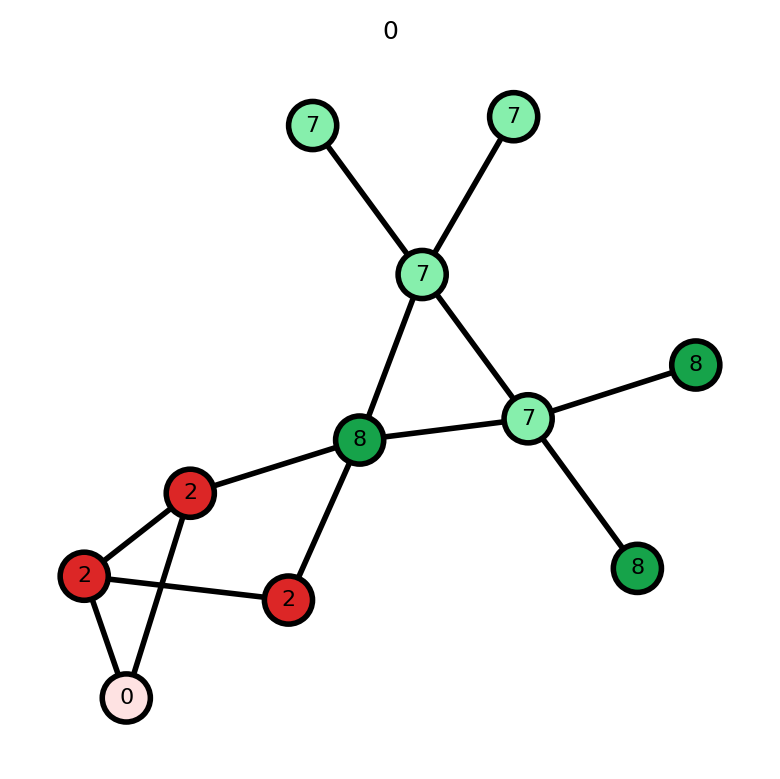

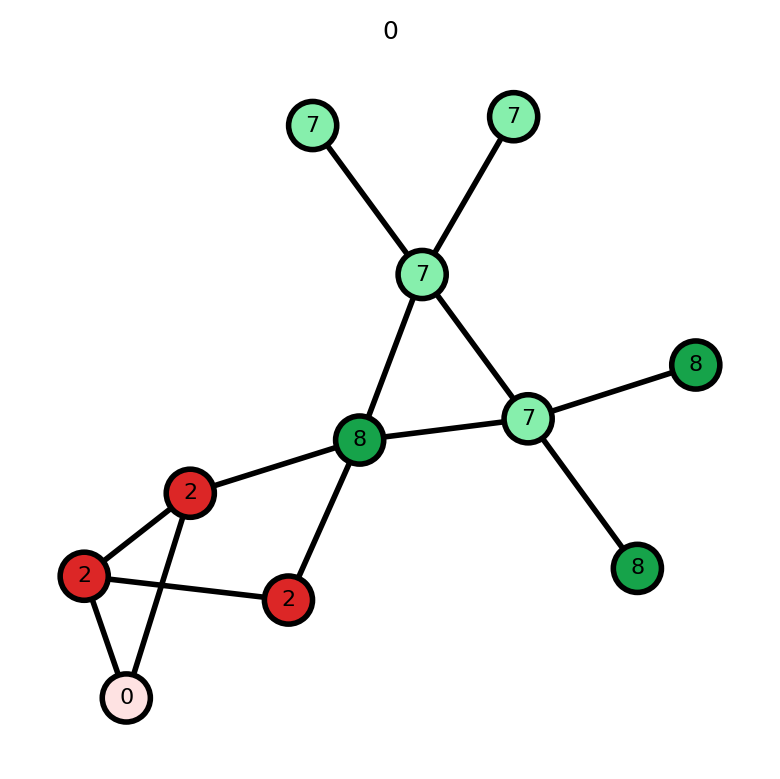

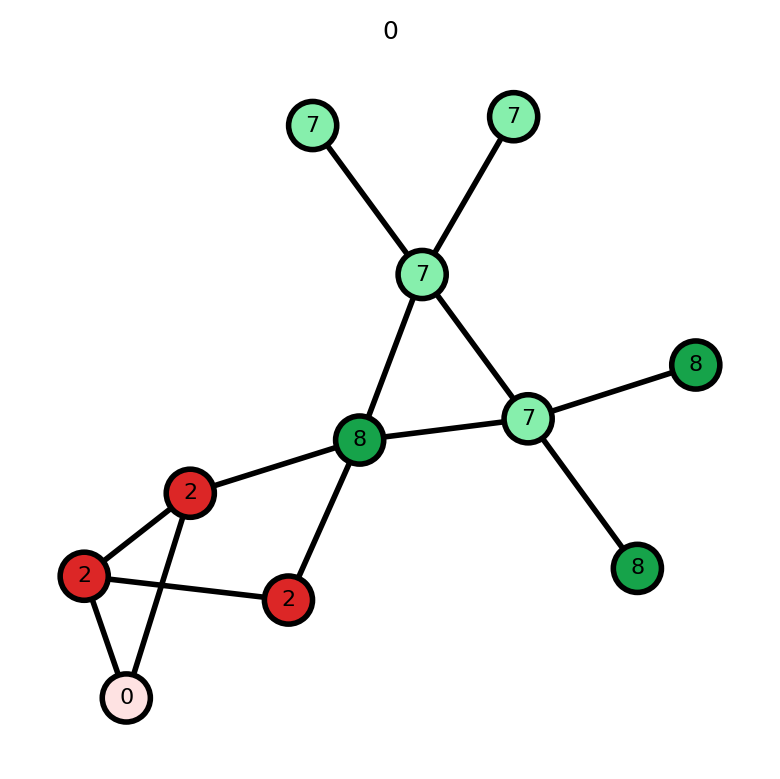

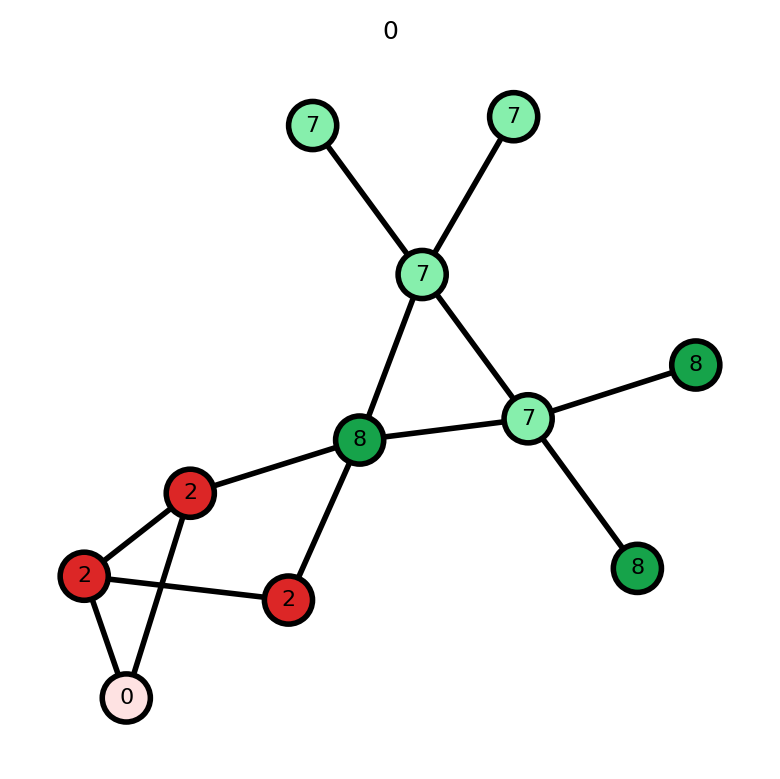

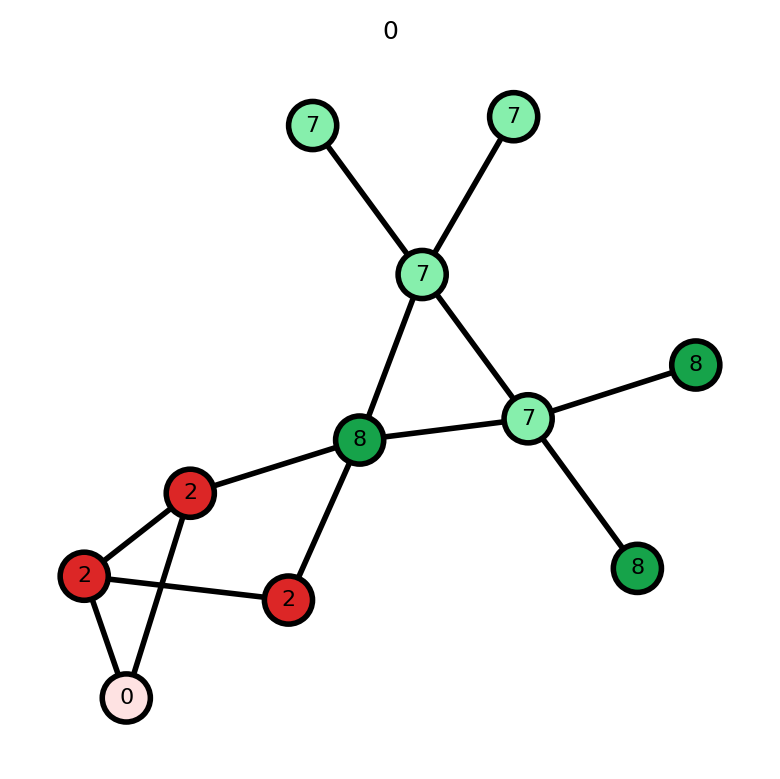

In [8]:
print('Compare the graphs produced at each decoding stage.')
n_samples = 1
sample_variants = graph_generator.sample(n_samples, return_decode_stages=True)

for variant_key in sample_variants:
    variant_samples = sample_variants[variant_key]
    plot_artificial_graphs(
        variant_samples,
        n_cols=n_samples,
        titles=[f'{idx}' for idx in range(len(variant_samples))],
    )